In [ ]:
import numpy as np                               
import pandas as pd                              
import matplotlib.pyplot as plt                  
import seaborn as sns                            

# from dateutil.relativedelta import relativedelta 
# from scipy.optimize import minimize              

import warnings                                  
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# !uv add pyarrow

In [3]:
use_cols = [
    'actual_worth', 'area_id', 'area_name_en', 'building_name_en', 'has_parking', 'instance_date', 'master_project_en', 'meter_rent_price', 'meter_sale_price', 'nearest_landmark_en', 'nearest_mall_en', 'nearest_metro_en', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3', 'procedure_area', 'procedure_id', 'procedure_name_en', 'project_name_en', 'project_number', 'property_sub_type_en', 'property_sub_type_id', 'property_type_en', 'property_type_id', 'property_usage_en', 'reg_type_en', 'reg_type_id', 'rent_value', 'rooms_en', 'trans_group_en', 'trans_group_id', 'transaction_id'
]
df = pd.read_csv(
    "/home/lex/Downloads/trans_13_02_2026.csv",
    usecols=use_cols,
    engine="pyarrow",
    parse_dates=['instance_date']
)
# rm_cols = ['RN', 'TOTAL', 'DEFAULT_SORT'] + ['trans_group_ar', 'procedure_name_ar', 'property_type_ar', 'property_sub_type_ar', 'property_usage_ar', 'reg_type_ar', 'area_name_ar', 'building_name_ar', 'project_name_ar', 'master_project_ar', 'nearest_landmark_ar', 'nearest_metro_ar', 'nearest_mall_ar','rooms_ar']
df.sample(10).T

,1659206,549404,579079,664491,102430,265159,1355423,1135327,216387,413103
actual_worth,770003.0,471808.0,755650.0,323400.0,1870741.0,350000.0,3856929.0,7599888.0,1410000.0,530000.0
area_id,484,505,343,462,330,343,482,463,526,441
area_name_en,Nadd Hessa,Madinat Hind 4,Al Warsan First,Madinat Al Mataar,Marsa Dubai,Al Warsan First,Hadaeq Sheikh Mohammed Bin Rashid,Wadi Al Safa 7,Business Bay,Al Barsha South Fourth
building_name_en,JADE RESIDENCE,VIRIDIS D,OLIVZ RESIDENCE BLOCK 1,CELESTIA B,MARINA HEIGHTS 1,T-04,Club Drive-Tower A,,U-BORA TOWER 1,Binghatti Azure
has_parking,1,1,1,1,1,0,1,0,1,1
instance_date,21-05-2015,07-12-2016,26-04-2024,24-11-2022,02-09-2013,09-07-2015,04-01-2024,05-01-2021,18-06-2025,24-04-2024
master_project_en,Silicon Oasis,DAMAC HILLS 2,WARSAN FIRST DEVELOPMENT,Dubai South Residential District,Dubai Marina,International City Phase 1,Dubai Hills Estate,Arabian Ranches II,Business Bay,Jumeirah Village Circle
meter_rent_price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meter_sale_price,10598.8,13069.47,8696.63,7605.83,9593.54,7865.17,26085.01,10325.93,9704.06,14714.05
nearest_landmark_en,IMG World Adventures,,Dubai International Airport,Expo 2020 Site,Burj Al Arab,,,Motor City,Downtown Dubai,Sports City Swimming Academy


In [37]:
# df[df.instance_date.dt.year >2020]
df.instance_date = pd.to_datetime(df.instance_date, errors='coerce')
df.index = df.instance_date
df = df[
    (df.instance_date.dt.year >= 2020)
    & (df.instance_date.dt.year < 2026)
    ]
# df.shape
# df.sample(10).T
# df.dtypes
# df.iloc[10180:10190].T
# df.index.max()

<Axes: xlabel='instance_date'>

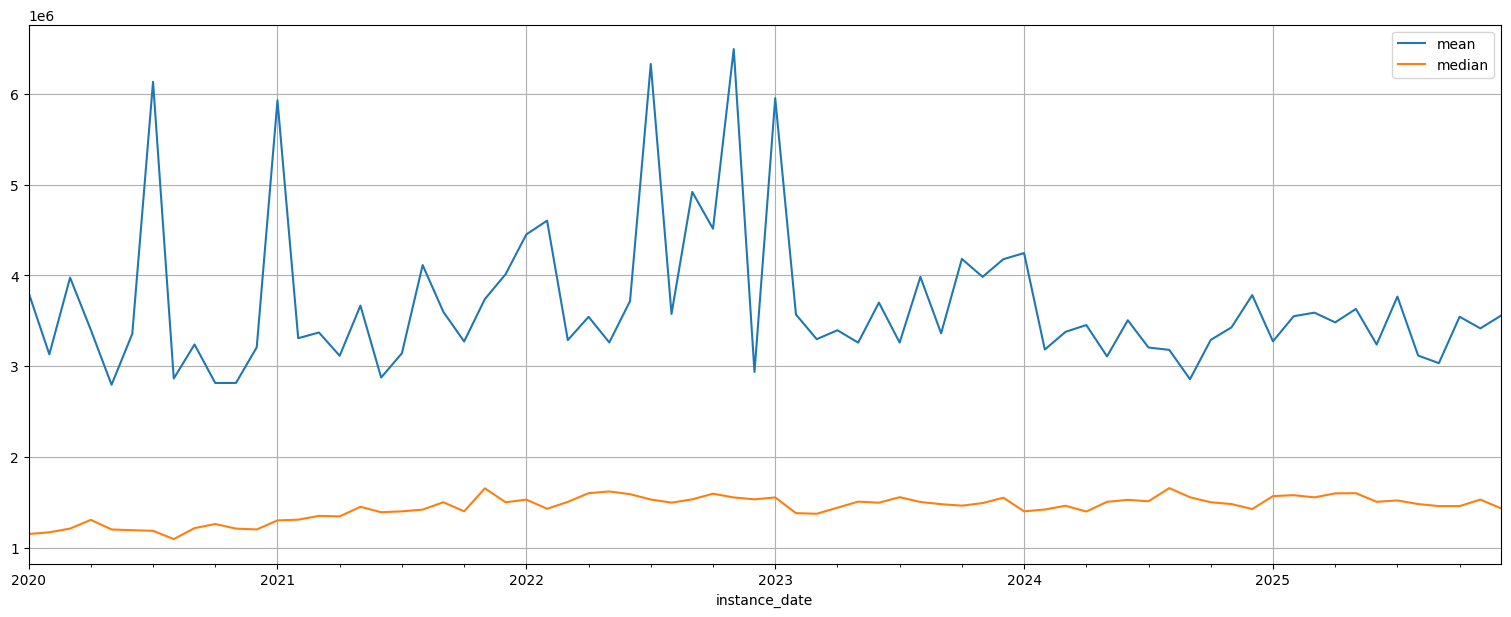

In [57]:
df.groupby(
    # df.instance_date.dt.month, 
    df.instance_date.dt.to_period("M")
).actual_worth\
    .agg([
        # 'sum', 'count', 
        'mean', 'median'
    ])\
    .plot(
    grid=True,
    figsize=(19,7)
)

In [58]:
df.groupby(
    # df.instance_date.dt.month, 
    df.instance_date.dt.to_period("M")
)\
    # .boxplot(subplots=False, rot=90, by='actual_worth')